# Detecção de Câncer de Pulmão em Imagens Médicas com Deep Learning


Objetivo: Treinar/Testar um modelo de Deep Learning com arquitetura de Rede Neural Convolucional.


### Carregando os Pacotes

In [1]:
# Imports
import os

import cv2
import random
import tensorflow
import keras
import itertools
import matplotlib as m
import numpy as np
import matplotlib.pyplot as plt
from keras import backend as K
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Activation, Flatten, Dense
from tensorflow.keras.utils import img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input
from keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import imutils
from imutils import paths
import argparse
from keras.models import load_model

2026-02-23 18:35:40.333696: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-23 18:35:40.346616: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-23 18:35:40.742341: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-23 18:35:43.411309: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

### Carregando as Imagens

In [2]:
# Diretório das imagens em disco
imagens_treino = "./dados/treino/"

# Listas para as imagens e labels
imagens = []
labels = []

In [3]:
# Lista as imagens do diretório
imagePaths = sorted(list(paths.list_images(imagens_treino)))

# com o shuffle embaralhamos as imagens
# isso serve para que na hora de dividir entre treino e teste o modelo veja bem cada classe
random.seed(42) # fixa o embaralhamento, para que qualquer pessoa que rode o código obtenhaos mesmos resultados
random.shuffle(imagePaths)

In [4]:
# Loop pelas imagens e leitura com OpenCV
for imagePath in imagePaths:
    
    # Ler as imagem com o cv2
    image = cv2.imread(imagePath)
    
    # Redimensiona para 40x40 pixels
    image = cv2.resize(image, (40,40))
    
    # Converte a imagem para array
    # extrai o rgb de cada um dos pixels da imagem
    # um pixel branco vira [255, 255, 255]
    image = img_to_array(image)
    
    # Adiciona na lista de imagens
    imagens.append(image)
    
    # Extrai o label
    # no final de cada imagem tem pos/neg informando se é câncer ou não
    # o label é como um gabarito de cada imagem para o modelo
    label = imagePath[-7:-4]
    
    # Define o valor 0 ou 1 para o label
    if label == "pos":
        label = 1
    else:
        label = 0
        
    # Adiciona na lista de labels
    labels.append(label)

In [5]:
# Normalização das imagens
# divide os valores de cada pixel de cada imagem, para a escala ficar de 0-1
imagens = np.array(imagens, dtype = "float") / 255.0

# Carrega os labels
labels = np.array(labels)

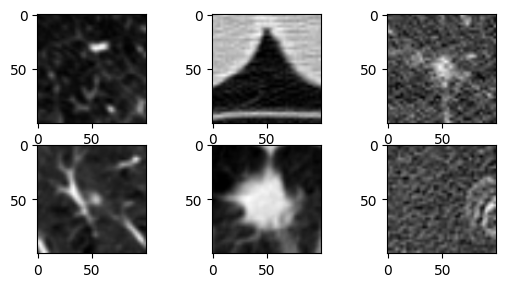

In [6]:
# Plot das imagens
for i, images in enumerate(imagePaths[:6]):
    img = cv2.imread(images)
    img = cv2.resize(img, (100, 100))
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.grid(False)
plt.show()

### Pré-Processamento das Imagens

In [7]:
# Divisão em treino/teste com proporção 75/25
x_treino, x_teste, y_treino, y_teste = train_test_split(imagens, labels, test_size = 0.25, random_state = 42)

In [8]:
print('='*30)
print('Shape da váriavel x_treino')
print('='*30)
print(f'Total de imagens: {x_treino.shape[0]}\
      \nAltura: {x_treino.shape[1]} - Largura: {x_treino.shape[2]}\
      \nNúmero de canais de cores: {x_treino.shape[3]}')

print()
print('='*30)
print('Shape da váriavel x_teste')
print('='*30)
print(f'Total de imagens: {x_teste.shape[0]}\
      \nAltura: {x_teste.shape[1]} - Largura: {x_teste.shape[2]}\
      \nNúmero de canais de cores: {x_teste.shape[3]}')

Shape da váriavel x_treino
Total de imagens: 2206      
Altura: 40 - Largura: 40      
Número de canais de cores: 3

Shape da váriavel x_teste
Total de imagens: 736      
Altura: 40 - Largura: 40      
Número de canais de cores: 3


In [9]:
# One-Hot Encoding
y_treino = to_categorical(y_treino, num_classes = 2)
y_teste = to_categorical(y_teste, num_classes = 2)

- **One-Hot Encoding**  

Com o One-Hot eu transformo cada valor dos labels é um array com dois valores.  
Exemplo:  
sem câncer [0] virou [1,0]  
câncer [1] virou [0,1]

Por que fazer isso?  
A camada de saída da CNN usa Softmax, que gera uma probabilidade para cada classe.

### Construção do Modelo

In [11]:
# Hiperparâmetros

# Número de épocas
epochs = 50

# Tamanho do batch
batch_size = 32

- O que é uma Época?  
Uma época é quando o modelo vê todas as imagens de treino uma vez completa.  
Definir epochs = 50 significa que esse ciclo se repete 50 vezes.

- O que é um Batch?  
O batch define quantas imagens o modelo vai ver de uma vez antes de atualizar seus pesos.  
Depois do modelo ver todas as imagens de treino, as imagens são embaralhadas e então começa uma nova época.  
Para saber quantos batch terá por época dividimos o total de imagens pelo número de imagens vistas de uma vez.  
68 batches por época  (2206 ÷ 32)

In [12]:
# Modelo CNN
# definindo a arquitetura do modelo
class ModeloCNN:
    
    @staticmethod
    def build(width, height, depth, classes):
        
        # Cria a sequência de camadas
        model = Sequential()
        
        # Shape de entrada
        inputShape = (height, width, depth)

        # Formato das imagens
        if K.image_data_format() == "channels_first":
            inputShape = (depth, height, width)
        
        # Primeira camada convolucional com ativação Relu e MaxPooling
        
        model = Sequential()
        model.add(Input(shape=(height, width, depth)))  # ← adiciona essa linha
        model.add(Conv2D(20, (5, 5)))                   # ← remove o input_shape daqui
        model.add(Activation("relu"))
        model.add(MaxPooling2D(pool_size = (2, 2), strides = (2, 2)))

        # Segunda camada convolucional com ativação Relu e MaxPooling
        model.add(Conv2D(50, (5, 5), padding = "same"))
        model.add(Activation("relu"))
        model.add(MaxPooling2D(pool_size = (2, 2), strides = (2, 2)))

        # Primeira camada totalmente conectada com ativação Relu
        model.add(Flatten())
        model.add(Dense(500))
        model.add(Activation("relu"))

        # Camada de saída com classificação softmax
        model.add(Dense(classes))
        model.add(Activation("softmax"))

        return model

In [13]:
# Criando o modelo
modelo_cnn = ModeloCNN.build(width = 40, height = 40, depth = 3, classes = 2)

2026-02-23 18:36:59.287007: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [14]:
# Taxa de aprendizagem
lr = 1e-3 # lr = 0.001 controla o tamanho da atualização dos pesos em cada ajuste:

In [15]:
# Cria o otimizador com algoritmo Adam
otimizador = Adam(learning_rate=lr)

# Compila o modelo com o otimizador, função de custo e métricas
modelo_cnn.compile(optimizer = otimizador, loss = "categorical_crossentropy", metrics = ["accuracy"])

- **Otimizador Adam**  

O otimizador é o algoritmo que atualiza os pesos da rede neural após cada batch.

- **A Função de Custo (Loss)**

```pythonloss = "categorical_crossentropy```
É a fórmula que mede o erro do modelo — o quanto a previsão foi diferente do label real. Exemplo:  
Modelo previu  → [0.92, 0.08]  (92% sem câncer, 8% com câncer)  
Label real     → [1.0,  0.0]   (era sem câncer de fato)  

In [ ]:
# Sumário do modelo
modelo_cnn.summary()

### Treinamento e Relatório

In [ ]:
def gerador_infinito(x, y, batch_size, aug):
    gen = aug.flow(x, y, batch_size=batch_size, shuffle=True)
    for batch in itertools.cycle(gen):
        yield batch

In [17]:
# Treina o modelo com dados de treino
print('Iniciando o treinamendo do modelo...\n')

hist = modelo_cnn.fit(gerador_infinito(x_treino, y_treino, batch_size, aug),
                      validation_data=(x_teste, y_teste),
                      steps_per_epoch=len(x_treino) // batch_size,
                      epochs=epochs,
                      verbose=1)


print("\nTreinamento Concluído.\n")

Iniciando o treinamendo do modelo...

Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.7711 - loss: 0.4987 - val_accuracy: 0.8356 - val_loss: 0.3767
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.8569 - loss: 0.3698 - val_accuracy: 0.8859 - val_loss: 0.2848
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.8786 - loss: 0.3131 - val_accuracy: 0.8859 - val_loss: 0.2890
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.8832 - loss: 0.2995 - val_accuracy: 0.9198 - val_loss: 0.2255
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.8928 - loss: 0.2776 - val_accuracy: 0.9375 - val_loss: 0.1973
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9177 - loss: 0.2472 - val_accuracy: 0.9457 - val_loss: 0.1761
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.9140 - loss: 0.2349 - val_accuracy: 0.9375 - val_loss: 0.1914
Epoch 8/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.9163 - l

```aug.flow(x_treino, y_treino, batch_size=batch_size)```  
É a fonte dos dados de treino. Em vez de passar as imagens diretamente, passa pelo gerador de imagens.

```validation_data=(x_teste, y_teste)```  
São os dados que o modelo nunca vê durante o treino, usados para medir o desempenho a cada época.

```steps_per_epoch = len(x_treino) // batch_size```  
Define quantos batches formam uma época completa.

```verbose = 1```  
Controla o que aparece na tela durante o treino.  
verbose=0  → silencioso, não mostra nada  
verbose=1  → barra de progresso detalhada   
verbose=2  → mostra só uma linha por época

- **O que o hist guarda?**  

O retorno do .fit() armazenando todo o histórico do treinamento.

In [18]:
# Calculamos a performance do modelo com dados de teste
# .evaluate() testa o modelo com dados que ele nunca viu e retorna as métricas configuradas no .compile()
score = modelo_cnn.evaluate(x_teste, y_teste, verbose = 1)
print(f"Acurácia do modelo em teste: {score[1] * 100:.2f}%" )

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9565 - loss: 0.1266
Acurácia do modelo em teste: 95.65%


---
- **argmax**

O argmax pega o vetor de probabilidades e retorna o índice do maior valor — ou seja, a classe vencedora.
```
np.argmax([0.97, 0.03])  →  0
np.argmax([0.08, 0.92])  →  1
np.argmax([0.85, 0.15])  →  0
```
---

- **classification_report**

Compara os dois vetores e gera um relatório completo com 4 métricas para cada classe:
```
              precision  recall  f1-score  support

              0    0.94     0.96     0.95      368
              1    0.96     0.94     0.95      368

     accuracy                        0.95      736
```

---
- **O que cada métrica significa?**

**Precision** — "Dos que o modelo disse ser câncer, quantos realmente eram?"

Modelo apontou 100 como câncer  
→  96 eram câncer de verdade  
→  4 eram falsos alarmes

Precision = 96%


**Recall** — "Dos que realmente tinham câncer, quantos o modelo encontrou?"

Havia 100 casos reais de câncer  
→  modelo detectou 94  
→  deixou escapar 6  

Recall = 94%


**F1-Score** — Média equilibrada entre Precision e Recall, útil quando as duas métricas importam igualmente:

F1 = equilíbrio entre não dar falso alarme e não deixar caso real escapar


**Support** — Simplesmente quantas imagens de cada classe existem no teste.

---

In [19]:
# métricas do modelo
predY = modelo_cnn.predict(x_teste)
print(classification_report(np.argmax(y_teste, axis=1), np.argmax(predY, axis=1)))

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       370
           1       0.95      0.96      0.96       366

    accuracy                           0.96       736
   macro avg       0.96      0.96      0.96       736
weighted avg       0.96      0.96      0.96       736



In [20]:
# Salva o modelo 
modelName = "./modelo/modelo_cnn.keras"
os.makedirs("./modelo", exist_ok=True)
modelo_cnn.save(modelName)

### Testar o modelo

In [37]:
# mude o número para selecionar a imagem de teste
image = 3

if image == 1:
    image = "./dados/teste/imagem1_cancer.png"
elif image == 2:
    image = "./dados/teste/imagem2_cancer.png"
elif image == 3:
    image = "./dados/teste/imagem3_no_cancer.png"
else:
    image = "./dados/teste/imagem4_no_cancer.png"

In [38]:
# Define o local do modelo
model = "./modelo/modelo_cnn.keras"

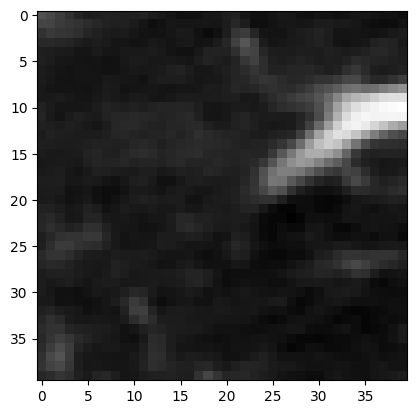

In [39]:
# Carrega a imagem
image = cv2.imread(image)
orig = image.copy()
plt.imshow(image)
plt.show()

In [40]:
# Pré-processamento da imagem
image = cv2.resize(image, (40, 40))
image = image.astype("float") / 255.0
image = img_to_array(image)
image = np.expand_dims(image, axis = 0)

In [41]:
# Carrega o modelo treinado
model = load_model(model)

In [42]:
# Fazemos a previsão
score = model.predict(image)[0]

# Extraímos a classe da previsão
label = np.argmax(model.predict(image), axis=1)[0]

# De acordo com o label, definimos a classificação final
if label == 0:
    label = "No Cancer"
else:
    label = "Cancer"

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [43]:
# Calcular o nível de confiança
# Extrai a maior probabilidade das previsões do modelo
proba = max(score)

# Print
print("Nível de confiança = {0:.2f}%".format(proba*100))

# aumenta o tamanho da imagem para uma melhor visualização
# orig é a imagem em forma de array
# output também é um array
output = imutils.resize(orig, width = 400)

# Verifica a probabilidade
# coloca uma camada extra de segurança
if proba*100 > 95:
    out = f"{label}: {proba * 100:.2f}%"
    color = (0,255,0)
else:
    out = f"{'Not detected'}"
    color = (255,0,0)

# Texto impresso na imagem
texto = cv2.putText(output, out, (10, 25),  cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

Nível de confiança = 98.69%


**Cada parâmetro do `putText`**
```
output                    →  imagem onde o texto será escrito
out                       →  o texto em si ("Cancer: 99.92%" ou "Not detected")
(10, 25)                  →  posição do texto (x=10, y=25 pixels)
cv2.FONT_HERSHEY_SIMPLEX  →  estilo da fonte
0.7                       →  tamanho da fonte
color                     →  cor (verde ou vermelho)
2                         →  espessura do texto em pixels
```
O `putText` não cria uma imagem nova — ele **altera os pixels** do array `output` na posição (10, 25) diretamente na mémoria.

---

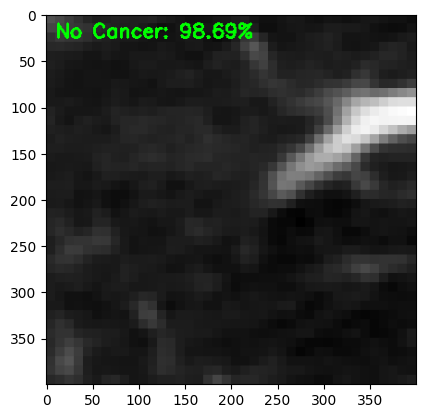

In [44]:
# plotando a imagem com o texto
plt.imshow(output)
plt.show()